# Structural Estimation

This notebook implements the dynamic discrete choice model from `slides.tex`.

In [1]:
# Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize
from scipy.special import logsumexp
from scipy.stats import norm
import multiprocessing
from concurrent.futures import ProcessPoolExecutor, as_completed
import time

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax.scipy.special import logsumexp as jax_logsumexp

### Load Data

In [2]:
df = pd.read_csv("./kkbox-subsample/panel_user_month.csv")

# user_ids = pd.Series(df["msno"].unique()).iloc[:300].tolist()
# df = df[df["msno"].isin(user_ids)].copy()

# Map observed statuses to model actions
status_to_action = {
    "churn": 0,
    "active": 1,
    "paused": 2,
}
df["action"] = df["subscription_status"].map(status_to_action)

df = df.sort_values(["msno", "user_tenure"]).reset_index(drop=True)

# Previous action for inertia term; initialize first month as previous active
df["prev_action"] = df.groupby("msno")["action"].shift(1)
df["prev_action"] = df["prev_action"].fillna(1).astype(int)

df["R_i"] = df.groupby("msno")["auto_renewal"].transform("first").astype(float)
df["p_i"] = df.groupby("msno")["price"].transform("first").astype(float)

df.head()

,msno,user_tenure,subscription_status,monthly_hours,cum_hours,auto_renewal,transaction_date,membership_expire_date,price,action,prev_action,R_i,p_i
0,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,0,active,39.826280,0.000000,0.0,20150215.0,20150317.0,149.0,1,1,0.0,149.0
1,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,1,active,16.865030,39.826280,0.0,20150320.0,20150419.0,149.0,1,1,0.0,149.0
2,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,2,active,20.236815,56.691311,0.0,20150421.0,20150521.0,149.0,1,1,0.0,149.0
3,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,3,active,17.657869,76.928126,0.0,20150522.0,20150621.0,149.0,1,1,0.0,149.0
4,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,4,active,11.805867,94.585995,0.0,20150621.0,20150721.0,149.0,1,1,0.0,149.0


In [3]:
# Discretize accumulated hours into bins

hour_edges = np.array([0.0, 10.0, 50.0, 100.0, np.inf])
H = len(hour_edges) - 1

df["h_bin"] = pd.cut(
    df["cum_hours"],
    bins=hour_edges,
    include_lowest=True,
    labels=False,
).astype(int)

df[["msno", "cum_hours", "h_bin"]].head(10)

,msno,cum_hours,h_bin
0,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,0.000000,0
1,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,39.826280,1
2,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,56.691311,2
3,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,76.928126,2
4,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,94.585995,2
5,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,106.391862,3
6,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,108.420437,3
7,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,108.420437,3
8,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,121.918446,3
9,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,122.889533,3


### Cumulative listening over tenure

Each line traces one user's accumulated listening hours (`cum_hours`) against months since first observation (`user_tenure`). The right panel summarizes the cross-sectional distribution at each tenure month (median and 25th–75th percentiles). Horizontal dashed lines mark the hour-bin edges used in the state space. Both panels truncate at the latest tenure month where more than 50% of users remain in the sample.

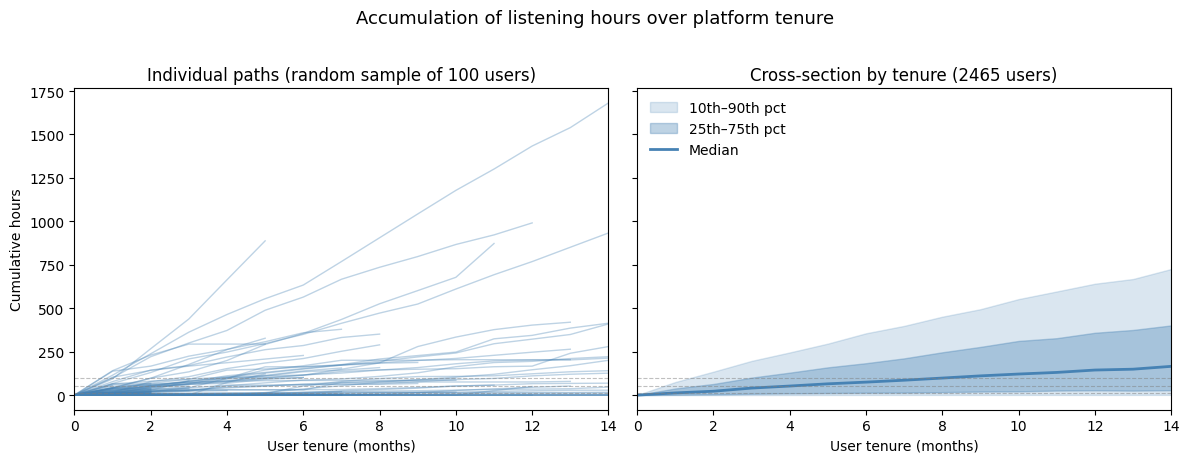

Users: 2465 | Observations: 21,812 | Max tenure: 25 months | Plot capped at tenure 14


In [4]:
plot_df = df.sort_values(["msno", "user_tenure"]).copy()
n_users = plot_df["msno"].nunique()

# Cross-sectional summary by tenure month
tenure_summary = (
    plot_df.groupby("user_tenure", as_index=False)["cum_hours"]
    .agg(
        median="median",
        p25=lambda s: s.quantile(0.25),
        p75=lambda s: s.quantile(0.75),
        p10=lambda s: s.quantile(0.10),
        p90=lambda s: s.quantile(0.90),
        n_users="count",
    )
)

# Truncate at the latest tenure where >50% of users remain
max_tenure_plot = int(
    tenure_summary.loc[tenure_summary["n_users"] > 0.2 * n_users, "user_tenure"].max()
)
tenure_summary = tenure_summary[tenure_summary["user_tenure"] <= max_tenure_plot]

# Spaghetti sample: fixed seed for reproducibility
rng = np.random.default_rng(0)
sample_users = rng.choice(plot_df["msno"].unique(), size=min(100, n_users), replace=False)
spaghetti = plot_df[
    plot_df["msno"].isin(sample_users) & (plot_df["user_tenure"] <= max_tenure_plot)
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

# --- Left: individual trajectories ---
ax0 = axes[0]
for msno, g in spaghetti.groupby("msno"):
    ax0.plot(
        g["user_tenure"],
        g["cum_hours"],
        color="steelblue",
        alpha=0.35,
        linewidth=1.0,
    )
for y in hour_edges[1:-1]:
    ax0.axhline(y, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax0.set_xlabel("User tenure (months)")
ax0.set_ylabel("Cumulative hours")
ax0.set_title(f"Individual paths (random sample of {len(sample_users)} users)")
ax0.set_xlim(0, max_tenure_plot)

# --- Right: cross-sectional bands ---
ax1 = axes[1]
t = tenure_summary["user_tenure"]
ax1.fill_between(t, tenure_summary["p10"], tenure_summary["p90"], color="steelblue", alpha=0.2, label="10th–90th pct")
ax1.fill_between(t, tenure_summary["p25"], tenure_summary["p75"], color="steelblue", alpha=0.35, label="25th–75th pct")
ax1.plot(t, tenure_summary["median"], color="steelblue", linewidth=2.0, label="Median")
for y in hour_edges[1:-1]:
    ax1.axhline(y, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax1.set_xlabel("User tenure (months)")
ax1.set_title(f"Cross-section by tenure ({n_users} users)")
ax1.legend(loc="upper left", frameon=False)
ax1.set_xlim(0, max_tenure_plot)

fig.suptitle("Accumulation of listening hours over platform tenure", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

print(
    f"Users: {n_users} | Observations: {len(plot_df):,} | "
    f"Max tenure: {plot_df['user_tenure'].max()} months | "
    f"Plot capped at tenure {max_tenure_plot}"
)

In [5]:
# Build empirical active-user transition matrix for h_bin
# T[h, h'] = P(h_{t+1}=h' | h_t=h, a_t=1)

active_rows = df.copy()
active_rows["h_bin_next"] = active_rows.groupby("msno")["h_bin"].shift(-1)
active_rows = active_rows[(active_rows["action"] == 1) & (active_rows["h_bin_next"].notna())].copy()
active_rows["h_bin_next"] = active_rows["h_bin_next"].astype(int)
counts = np.zeros((H, H), dtype=float)
for _, r in active_rows.iterrows():
    counts[int(r["h_bin"]), int(r["h_bin_next"])] += 1.0
T = np.zeros((H, H), dtype=float)
for h in range(H):
    row_sum = counts[h].sum()
    if row_sum > 0:
        T[h] = counts[h] / row_sum
    else:
        T[h, h] = 1.0

pd.DataFrame(T)

,0,1,2,3
0,0.737665,0.198556,0.043622,0.020156
1,0.000000,0.774460,0.211410,0.014130
2,0.000000,0.000000,0.662676,0.337324
3,0.000000,0.000000,0.000000,1.000000


In [6]:
# Enumerate the dynamic state space
# Omega_t = (h_t, a_{t-1})

a_prev_vals = np.array([0, 1, 2], dtype=int)

state_tuples = []
for h in range(H):
    for a_prev in a_prev_vals:
        state_tuples.append((int(h), int(a_prev)))

state_to_idx = {s: i for i, s in enumerate(state_tuples)}
idx_to_state = {i: s for s, i in state_to_idx.items()}

n_states = len(state_tuples)
n_actions = 3  # churn, active, pause

In [7]:
# Transition matrices P[a, s, s_next]
# Build action-specific transition tensor under model assumptions:
#   - a=0 churn: absorbing terminal action with zero continuation value,
#                implemented as self-transition (continuation still zero since v0=0 forever)
#   - a=1 active: h transitions via empirical T, next a_prev = 1
#   - a=2 pause: h is frozen, next a_prev = 2

P = np.zeros((3, n_states, n_states), dtype=float)

for s_idx, (h_bin, a_prev) in enumerate(state_tuples):
    # a = 0 (churn): absorbing
    P[0, s_idx, s_idx] = 1.0

    # a = 1 (active): draw h' from empirical active transition, set a_prev' = 1
    for h_next in range(H):
        s_next = (int(h_next), 1)
        s_next_idx = state_to_idx[s_next]
        P[1, s_idx, s_next_idx] += T[h_bin, h_next]

    # a = 2 (pause): keep h fixed, set a_prev' = 2
    s_next_pause = (int(h_bin), 2)
    s_next_pause_idx = state_to_idx[s_next_pause]
    P[2, s_idx, s_next_pause_idx] = 1.0

print("Transition tensor shape:", P.shape)

Transition tensor shape: (3, 12, 12)


In [8]:
# map observed panel rows to state indices used by DP

def attach_state_index(df_panel, state_to_idx):
    df_out = df_panel.copy()
    df_out["state_tuple"] = list(
        zip(
            df_out["h_bin"].astype(int),
            df_out["prev_action"].astype(int),
        )
    )
    df_out["state_idx"] = df_out["state_tuple"].map(state_to_idx)

    missing = df_out["state_idx"].isna().sum()
    if missing > 0:
        raise ValueError(f"Found {missing} rows with state not in state space.")

    df_out["state_idx"] = df_out["state_idx"].astype(int)
    return df_out


df_model = attach_state_index(df, state_to_idx)
df_model[["msno", "user_tenure", "action", "prev_action", "h_bin", "state_idx", "R_i", "p_i"]].head(10)

,msno,user_tenure,action,prev_action,h_bin,state_idx,R_i,p_i
0,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,0,1,1,0,1,0.0,149.0
1,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,1,1,1,1,4,0.0,149.0
2,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,2,1,1,2,7,0.0,149.0
3,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,3,1,1,2,7,0.0,149.0
4,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,4,1,1,2,7,0.0,149.0
5,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,5,1,1,3,10,0.0,149.0
6,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,6,2,1,3,10,0.0,149.0
7,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,7,1,2,3,11,0.0,149.0
8,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,8,1,1,3,10,0.0,149.0
9,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,9,0,1,3,10,0.0,149.0


In [9]:
# Vectorized index arrays used inside the objective

# One integer index per (R_i, p_i) type
unique_types = (
    df_model[["R_i", "p_i"]]
    .drop_duplicates()
    .sort_values(["R_i", "p_i"])
    .reset_index(drop=True)
)
type_pairs = list(zip(
    unique_types["R_i"].to_numpy(dtype=float),
    unique_types["p_i"].to_numpy(dtype=float),
))
type_to_idx = {pair: i for i, pair in enumerate(type_pairs)}

# One integer index per household (msno) for clustering and per-individual scores
_, hh_index_np = np.unique(df_model["msno"].to_numpy(), return_inverse=True)
hh_index_np = hh_index_np.astype(int)

# Observation-level arrays
s_idx_np = df_model["state_idx"].to_numpy(dtype=int)
a_obs_np = df_model["action"].to_numpy(dtype=int)
type_idx_np = np.array([
    type_to_idx[(float(R_i), float(p_i))]
    for R_i, p_i in zip(df_model["R_i"].to_numpy(), df_model["p_i"].to_numpy())
], dtype=int)

# State-level arrays for vectorized utility construction
h_of_state_np = np.array([s[0] for s in state_tuples], dtype=int)
a_prev_of_state_np = np.array([s[1] for s in state_tuples], dtype=int)

# Type-level arrays
R_type_np = unique_types["R_i"].to_numpy(dtype=float)
p_type_np = unique_types["p_i"].to_numpy(dtype=float)

print(
    f"n_individuals: {hh_index_np.max() + 1} | "
    f"n_types: {len(unique_types)} | "
    f"n_states: {len(state_tuples)} | "
    f"n_obs: {len(df_model)}"
)

n_individuals: 2465 | n_types: 10 | n_states: 12 | n_obs: 21812


### Flow utility specification

<div style="display:none">
$\newcommand{\bm}[1]{\mathbf{#1}}$
</div>

Each household $i$ has a time-invariant type $(R_i, p_i)$ (auto-renewal flag and price) and a time-varying state $\omega_t = (h_t, a_{t-1})$ collecting their accumulated-hours bin $h_t$ and the previous month's action $a_{t-1}$. In month $t$ they choose $a_t \in \{0, 1, 2\}$ representing churn, active, and paused subscriptions respectively, drawing iid Type-I EV shocks $\varepsilon_{ait}$. The deterministic component of flow utility is

$$
\begin{aligned}
v_0(\omega_t; \bm\theta) &= 0 \\
v_1(\omega_t; R_i, p_i, \bm\theta) &= \bar{u}_1 + \alpha R_i - \beta p_i + \eta \mathbf{1}\{a_{t-1} = 1\} + \gamma_{h_t} \\
v_2(\omega_t; \bm\theta) &= \bar{u}_2 + \eta \mathbf{1}\{a_{t-1} = 2\}
\end{aligned}
$$

Churn is normalized to zero. Because $\bar{u}_1$ enters as a level only $\gamma_h - \gamma_1$ is separately identified from $\bar{u}_1$, so we normalize the lowest-bin slope to $\gamma_1 \equiv 0$ (absorbed into $\bar{u}_1$) and estimate the deviations $\gamma_2, \ldots, \gamma_H$. The free-parameter vector is $\bm\theta = (\bar{u}_1, \bar{u}_2, \alpha, \beta, \eta, \gamma_2, \ldots, \gamma_H)$, with $4 + H$ entries.

### Nested fixed-point likelihood

<div style="display:none">
$\newcommand{\bm}[1]{\mathbf{#1}}$
</div>

Conditional on $\bm\theta$, the action-specific value function $\nu_a(\omega; \bm\theta)$ solves the Bellman equation
$$
\nu_a(\omega; \bm\theta)
= u_a(\omega; \bm\theta) + \delta \sum_{\omega'} P(\omega' \mid \omega, a) \, \mathrm{logsumexp}_{a'} \nu_{a'}(\omega'; \bm\theta).
$$
Under Type-I EV shocks the conditional choice probabilities (CCPs) are
$$
\Pr(a_t = a \mid \omega_t; \bm\theta) = \frac{\exp \nu_a(\omega_t; \bm\theta)}{\sum_{a'} \exp \nu_{a'}(\omega_t; \bm\theta)}.
$$

We estimate $\bm\theta$ by nested fixed-point MLE. For each candidate $\bm\theta$, the inner loop computes $\nu(\cdot; \bm\theta)$ by value iteration on the batched Bellman operator (vectorized across types so each $(R_i, p_i)$ shares the same $P$ but has a type-specific $u_a$). The outer loop maximizes
$$
\ell(\bm\theta) = \sum_{i=1}^N \sum_{t=1}^{T_i} \log \Pr(a_{it} \mid \omega_{it}; \bm\theta)
$$
using `scipy.optimize.minimize` with the JAX-computed analytic gradient. Standard errors are obtained from the JAX-computed Hessian (or its sandwich form when `robust_se=True`, clustering on the individual identifier).

### Discrete latent-class heterogeneity

<div style="display:none">
$\newcommand{\bm}[1]{\mathbf{#1}}$
</div>

Suppose households fall into $C$ unobserved latent classes. Conditional on class $c$, household $i$ has structural parameters $\bm\theta_c$ (some entries common across classes, others class-specific). Let $\mu_c \ge 0$ with $\sum_c \mu_c = 1$ be the population proportion of class $c$, parameterized via raw scores $\tilde\mu_c$ with $\tilde\mu_1 \equiv 0$:
$$
\mu_c = \frac{\exp(\tilde\mu_c)}{\sum_{c'} \exp(\tilde\mu_{c'})}.
$$
The household likelihood mixes the conditional likelihoods over classes:
$$
L_i = \sum_{c=1}^C \mu_c \prod_{t=1}^{T_i} \Pr(a_{it} \mid \omega_{it}; \bm\theta_c).
$$
For numerical stability we work in log-space, accumulating the conditional log-likelihoods
$$
\log L_{ic}^{(2)} = \sum_{t=1}^{T_i} \log \Pr(a_{it} \mid \omega_{it}; \bm\theta_c)
$$
within household via `segment_sum`, then mixing across classes with `logsumexp`:
$$
\log L_i = \mathrm{logsumexp}_c \bigl( \log L_{ic}^{(2)} + \log\mu_c \bigr).
$$

The inner NFXP loop is unchanged conceptually but adds a leading class dimension: $\bm{U}$ has shape $(C, T, A, S)$ and value iteration runs the same `logsumexp`-then-`einsum` recursion. Each class $c$ has its own action-specific value function $\nu_a^{(c)}(\omega)$ and CCPs.

**Bayesian posterior class probabilities.** Given observed choices $\bm y_i$, by Bayes' rule
$$
\Pr(i \in c \mid \bm y_i) = \frac{\mu_c \prod_t \Pr(a_{it} \mid \omega_{it}; \bm\theta_c)}{L_i} = \exp\bigl(\log L_{ic}^{(2)} + \log\mu_c - \log L_i\bigr),
$$
which is returned in `posterior_class_prob` (shape $N \times C$) at the optimum.

**API.** `estimate_ddc` accepts `n_classes` and `heterogenous_params` (a list of parameter names that vary across classes; the remainder are common). Valid names are `'u1_bar'`, `'u2_bar'`, `'alpha'`, `'beta'`, `'eta'`, each `'gamma_h'` for $h = 2, \ldots, H$, or the shorthand `'gamma'` for the full vector. The optimizer's flat parameter vector concatenates: heterogeneous coefficients (class-major), then common coefficients, then the $C - 1$ free $\tilde\mu_c$.

In [10]:
_NAMED_PARAMS_BASE = ("u1_bar", "u2_bar", "alpha", "beta", "eta")


def _canonical_param_names(H):
    """Names of the (4 + H) free structural parameters, in canonical order."""
    return list(_NAMED_PARAMS_BASE) + [f"gamma_{h}" for h in range(2, H + 1)]


def _resolve_hetero_params(heterogenous_params, H):
    """
    Convert a list of parameter names (or 'gamma' shorthand) to a sorted tuple
    of canonical indices in the (4 + H,)-length parameter vector.

    Canonical names in order:
        ['u1_bar', 'u2_bar', 'alpha', 'beta', 'eta', 'gamma_2', ..., f'gamma_{H}']

    'gamma' is shorthand for all free gamma_h (h = 2..H). 'gamma_1' is fixed at 0
    and cannot be made class-specific.
    """
    canonical = _canonical_param_names(H)
    name_to_idx = {name: i for i, name in enumerate(canonical)}

    if heterogenous_params is None:
        return ()

    indices = set()
    for name in heterogenous_params:
        if name == "gamma":
            for h in range(2, H + 1):
                indices.add(name_to_idx[f"gamma_{h}"])
        elif name == "gamma_1":
            raise ValueError("gamma_1 is normalized to 0 and cannot be heterogeneous.")
        elif name in name_to_idx:
            indices.add(name_to_idx[name])
        else:
            raise ValueError(
                f"Unknown parameter name '{name}'. "
                f"Valid: {canonical} (or 'gamma' for all gamma_h)."
            )

    return tuple(sorted(indices))


def _unpack_theta(theta_vec, H, n_classes, hetero_idx_arr, common_idx_arr):
    """
    Unpack the flat parameter vector into a per-class structural-params dict and the
    free mu vector.

    theta_vec ordering (class-major within the heterogeneous block):
        [hetero_param_0_class_0, hetero_param_1_class_0, ..., hetero_param_{n_h-1}_class_0,
         hetero_param_0_class_1, ..., hetero_param_{n_h-1}_class_{n_classes-1},
         common_param_0, ..., common_param_{n_c-1},
         mu_2_raw, ..., mu_{n_classes}_raw]    (mu_1_raw is fixed at 0)

    Each scalar field of the returned dict has shape (n_classes,); ``gamma`` has shape
    (H, n_classes) with the first row fixed at 0 (gamma_1 normalization).
    """
    theta_vec = jnp.asarray(theta_vec, dtype=jnp.float64)
    n_params = 4 + H
    n_hetero = int(hetero_idx_arr.shape[0])
    n_common = int(common_idx_arr.shape[0])
    hetero_size = n_hetero * n_classes

    theta_hetero = theta_vec[:hetero_size].reshape(n_hetero, n_classes, order="F")
    theta_common = theta_vec[hetero_size:hetero_size + n_common]
    mu_free = theta_vec[hetero_size + n_common:]

    theta_mat = jnp.zeros((n_params, n_classes), dtype=theta_vec.dtype)
    if n_common > 0:
        theta_common_bcast = jnp.broadcast_to(theta_common[:, None], (n_common, n_classes))
        theta_mat = theta_mat.at[common_idx_arr].set(theta_common_bcast)
    if n_hetero > 0:
        theta_mat = theta_mat.at[hetero_idx_arr].set(theta_hetero)

    gamma_free = theta_mat[5:5 + H - 1]                                   # (H-1, C)
    gamma = jnp.concatenate(
        [jnp.zeros((1, n_classes), dtype=theta_vec.dtype), gamma_free], axis=0
    )                                                                     # (H, C)
    return {
        "u1_bar": theta_mat[0],
        "u2_bar": theta_mat[1],
        "alpha": theta_mat[2],
        "beta": theta_mat[3],
        "eta": theta_mat[4],
        "gamma": gamma,
    }, mu_free


def _build_U_all_types(theta, R_type, p_type, h_of_state, a_prev_of_state):
    """
    Build the deterministic flow-utility tensor U with shape
    (n_classes, n_types, n_actions=3, n_states), where U[c, t, a, s] is the
    flow utility of action a in state s for type t under class c's parameters.

    theta : dict with scalar fields shaped (C,) and ``gamma`` shaped (H, C).
    """
    n_classes = theta["u1_bar"].shape[0]
    n_types = R_type.shape[0]
    n_states = h_of_state.shape[0]

    inertia_active = (a_prev_of_state == 1).astype(jnp.float64)           # (S,)
    inertia_pause = (a_prev_of_state == 2).astype(jnp.float64)            # (S,)
    gamma_state = theta["gamma"][h_of_state]                              # (S, C)

    active_type_level = (theta["u1_bar"][:, None]
                         + theta["alpha"][:, None] * R_type[None, :]
                         + theta["beta"][:, None] * p_type[None, :])      # (C, T)

    U0 = jnp.zeros((n_classes, n_types, n_states))
    U1 = (active_type_level[:, :, None]                                   # (C, T, 1)
          + theta["eta"][:, None, None] * inertia_active[None, None, :]   # (C, 1, S)
          + gamma_state.T[:, None, :])                                    # (C, 1, S)
    U2_cs = (theta["u2_bar"][:, None]
             + theta["eta"][:, None] * inertia_pause[None, :])            # (C, S)
    U2 = jnp.broadcast_to(U2_cs[:, None, :], (n_classes, n_types, n_states))

    return jnp.stack([U0, U1, U2], axis=2)                                # (C, T, 3, S)


def _bellman_solve(U_all, P, delta, max_iter):
    """
    Inner NFXP loop: solve the action-specific value-function fixed point

        Nu_a(s) = U_a(s) + delta * sum_{s'} P(s' | s, a) * logsumexp_a' Nu_a'(s')

    by batched value iteration, vectorized over latent classes and types.

    U_all : (C, T, A, S), P : (A, S, S)  ->  Nu : (C, T, A, S)
    """
    Nu0 = jnp.zeros_like(U_all)

    def body(i, Nu):
        cont_vals = jax_logsumexp(Nu, axis=2)                             # (C, T, S)
        EV = jnp.einsum("ask,ctk->ctas", P, cont_vals)                    # (C, T, A, S)
        return U_all + delta * EV

    return jax.lax.fori_loop(0, max_iter, body, Nu0)


def _negloglik_components(theta_vec, arrays, H, delta, bellman_iter,
                          n_classes, hetero_idx_arr, common_idx_arr):
    """
    Returns:
      log_L1 : (N,)        household log-likelihoods integrated over classes
      log_L2 : (N, C)      household log-likelihoods conditional on class
      log_mu : (C,)        log class proportions (mu_raw - logsumexp(mu_raw))
    """
    theta, mu_free = _unpack_theta(theta_vec, H, n_classes,
                                   hetero_idx_arr, common_idx_arr)
    U_all = _build_U_all_types(theta,
                               R_type=arrays["R_type"],
                               p_type=arrays["p_type"],
                               h_of_state=arrays["h_of_state"],
                               a_prev_of_state=arrays["a_prev_of_state"])
    Nu_all = _bellman_solve(U_all, arrays["P"], delta, bellman_iter)      # (C, T, A, S)

    # Gather per-observation action-specific values across classes
    Nu_perm = Nu_all.transpose(1, 3, 0, 2)                                # (T, S, C, A)
    Nu_obs = Nu_perm[arrays["type_idx"], arrays["s_idx"]]                 # (n_obs, C, A)

    a_obs = arrays["a_obs"]
    Nu_chosen = jnp.take_along_axis(Nu_obs, a_obs[:, None, None], axis=2)[:, :, 0]
    log_p_oc = Nu_chosen - jax_logsumexp(Nu_obs, axis=2)                  # (n_obs, C)

    log_L2 = jax.ops.segment_sum(
        log_p_oc, arrays["hh_index"], num_segments=arrays["n_individuals"]
    )                                                                     # (N, C)

    if n_classes > 1:
        mu_raw = jnp.concatenate(
            [jnp.zeros((1,), dtype=theta_vec.dtype), mu_free]
        )
    else:
        mu_raw = jnp.zeros((1,), dtype=theta_vec.dtype)
    log_mu = mu_raw - jax_logsumexp(mu_raw)                               # (C,)

    log_L1 = jax_logsumexp(log_L2 + log_mu[None, :], axis=1)              # (N,)
    return log_L1, log_L2, log_mu


def _negloglik(theta_vec, arrays, H, delta, bellman_iter,
               n_classes, hetero_idx_arr, common_idx_arr):
    """Summed negative log-likelihood."""
    log_L1, _, _ = _negloglik_components(
        theta_vec, arrays, H, delta, bellman_iter,
        n_classes, hetero_idx_arr, common_idx_arr,
    )
    return -jnp.sum(log_L1)


def _negloglik_hh(theta_vec, arrays, H, delta, bellman_iter,
                  n_classes, hetero_idx_arr, common_idx_arr):
    """Per-household negative log-likelihood. Shape (n_individuals,)."""
    log_L1, _, _ = _negloglik_components(
        theta_vec, arrays, H, delta, bellman_iter,
        n_classes, hetero_idx_arr, common_idx_arr,
    )
    return -log_L1


def _score_matrix(theta_vec, arrays, H, delta, bellman_iter,
                  n_classes, hetero_idx_arr, common_idx_arr):
    """
    Score matrix d(NLL_h)/d theta with shape (n_individuals, n_params).
    Used for clustered (sandwich) standard errors.
    """
    def f(th):
        return _negloglik_hh(th, arrays, H, delta, bellman_iter,
                             n_classes, hetero_idx_arr, common_idx_arr)
    return np.asarray(jax.jacrev(f)(theta_vec))


def _print_ddc_output(output, n_obs, n_individuals, H, n_classes,
                      hetero_idx, common_idx, robust_se, individual_var):
    """Prints DDC NFXP results in a nice table, separated by class."""
    B_hat = np.asarray(output["opt_beta"])                                # (4+H, C)
    se_theta = np.asarray(output["se_theta"], dtype=float).reshape(-1)
    ci_theta = np.asarray(output["ci_theta"], dtype=float)
    if ci_theta.ndim == 1:
        ci_theta = ci_theta.reshape(-1, 2)

    n_params = 4 + H
    canonical_names = _canonical_param_names(H)

    n_hetero = len(hetero_idx)
    n_common = len(common_idx)
    hetero_size = n_hetero * n_classes

    se_mat = np.zeros((n_params, n_classes), dtype=float)
    ci_mat = np.zeros((n_params, n_classes, 2), dtype=float)
    if n_hetero > 0:
        se_h = se_theta[:hetero_size].reshape(n_hetero, n_classes, order="F")
        ci_h = ci_theta[:hetero_size].reshape(n_hetero, n_classes, 2, order="F")
        for j, idx in enumerate(hetero_idx):
            se_mat[idx, :] = se_h[j]
            ci_mat[idx, :, :] = ci_h[j]
    if n_common > 0:
        se_c = se_theta[hetero_size:hetero_size + n_common]
        ci_c = ci_theta[hetero_size:hetero_size + n_common]
        for j, idx in enumerate(common_idx):
            se_mat[idx, :] = se_c[j]
            ci_mat[idx, :, :] = ci_c[j]

    print(output.get("message", ""))
    print(f"Converged in {output['num_iter']} iterations.")
    print()
    print(f"Log-likelihood: {output['opt_ll']:.4f}")
    print(f"Number of individuals: {n_individuals}")
    print(f"Number of observations: {n_obs}")
    print(f"Number of parameters estimated: {output['opt_theta'].shape[0]}")
    if n_classes > 1:
        print(f"Class proportions: {np.round(output['opt_mu_prob'], 6)}")
    if robust_se:
        print(f"Robust standard errors, clustered on the {individual_var} variable.")
    else:
        print("Standard errors are not robust and assume correct model specification.")
    print()

    widths = (12, 12, 11, 10, 10)
    header_top = (
        f"{'Coefficient':^{widths[0]}} | {'Estimate':^{widths[1]}} | "
        f"{'Std. Err.':^{widths[2]}} | {'[Confidence Interval]':^{widths[3] + widths[4] + 3}}"
    )
    divider = "-+-".join("-" * w for w in widths)

    if n_common > 0:
        print("Common Parameters")
        print(header_top)
        print(divider)
        for idx in common_idx:
            print(" | ".join([
                f"{canonical_names[idx]:<{widths[0]}}",
                f"{B_hat[idx, 0]:>{widths[1]}.6f}",
                f"{se_mat[idx, 0]:>{widths[2]}.6f}",
                f"{ci_mat[idx, 0, 0]:>{widths[3]}.5f}",
                f"{ci_mat[idx, 0, 1]:>{widths[4]}.5f}",
            ]))
        print()

    if n_hetero > 0:
        for c in range(n_classes):
            heading = f"Class {c + 1}"
            if n_classes > 1:
                heading += f" -- proportion: {output['opt_mu_prob'][c]:.6f}"
            print(heading)
            print(header_top)
            print(divider)
            for idx in hetero_idx:
                print(" | ".join([
                    f"{canonical_names[idx]:<{widths[0]}}",
                    f"{B_hat[idx, c]:>{widths[1]}.6f}",
                    f"{se_mat[idx, c]:>{widths[2]}.6f}",
                    f"{ci_mat[idx, c, 0]:>{widths[3]}.5f}",
                    f"{ci_mat[idx, c, 1]:>{widths[4]}.5f}",
                ]))
            print()


def _ddc_estimator(arrays, H, delta, bellman_iter, theta_init,
                   n_classes, hetero_idx, common_idx,
                   ci_alpha, robust_se, opt_method):
    """
    Estimates the dynamic discrete choice model by nested fixed-point MLE from a single
    initial value ``theta_init``. Returns the per-class B matrix, class proportions,
    posterior class probabilities, and standard errors from the JAX Hessian (sandwich
    form if ``robust_se=True``).
    """
    hetero_idx_arr = jnp.asarray(hetero_idx, dtype=jnp.int32)
    common_idx_arr = jnp.asarray(common_idx, dtype=jnp.int32)

    arrays_j = {k: (jnp.asarray(v) if isinstance(v, np.ndarray) else v)
                for k, v in arrays.items()}

    def _nll(th):
        return _negloglik(th, arrays_j, H, delta, bellman_iter,
                          n_classes, hetero_idx_arr, common_idx_arr)

    nll_jit = jax.jit(_nll)
    grad_jit = jax.jit(jax.grad(_nll))
    hess_jit = jax.jit(jax.hessian(_nll))

    def obj_np(th):
        return float(nll_jit(jnp.asarray(th, dtype=jnp.float64)))

    def grad_np(th):
        return np.asarray(grad_jit(jnp.asarray(th, dtype=jnp.float64)), dtype=float)

    result = minimize(
        fun=obj_np,
        jac=grad_np,
        x0=np.asarray(theta_init, dtype=float),
        method=opt_method,
    )

    opt_ll = -float(result.fun)
    opt_theta = result.x

    theta_dict, mu_free = _unpack_theta(jnp.asarray(opt_theta), H, n_classes,
                                        hetero_idx_arr, common_idx_arr)
    if n_classes > 1:
        mu_raw = jnp.concatenate([jnp.zeros((1,)), mu_free])
    else:
        mu_raw = jnp.zeros((1,))
    log_mu_prob = mu_raw - jax_logsumexp(mu_raw)
    mu_prob = np.asarray(jnp.exp(log_mu_prob))

    # Posterior class probabilities: Pr(c | y_i) = mu_c * L_ic / L_i
    log_L1, log_L2, _ = _negloglik_components(
        jnp.asarray(opt_theta), arrays_j, H, delta, bellman_iter,
        n_classes, hetero_idx_arr, common_idx_arr,
    )
    posterior_class_prob = np.asarray(
        jnp.exp(log_L2 + log_mu_prob[None, :] - log_L1[:, None])
    )

    # Structural-coefficient matrix B of shape (4+H, C), including gamma_1 = 0
    n_params = 4 + H
    B_hat = np.zeros((n_params, n_classes), dtype=float)
    B_hat[0] = np.asarray(theta_dict["u1_bar"])
    B_hat[1] = np.asarray(theta_dict["u2_bar"])
    B_hat[2] = np.asarray(theta_dict["alpha"])
    B_hat[3] = np.asarray(theta_dict["beta"])
    B_hat[4] = np.asarray(theta_dict["eta"])
    gamma_np = np.asarray(theta_dict["gamma"])                            # (H, C)
    B_hat[5:5 + H - 1] = gamma_np[1:]                                     # gamma_2..gamma_H

    H_obs = np.asarray(hess_jit(jnp.asarray(opt_theta, dtype=jnp.float64)))
    H_inv = np.linalg.pinv(H_obs)
    se_theta = np.sqrt(np.clip(np.diag(H_inv), 0.0, None))

    z = norm.ppf(1 - ci_alpha / 2)
    ci_theta = np.array(
        [(coef - z * se, coef + z * se) for coef, se in zip(opt_theta, se_theta)]
    )

    output = {
        "opt_ll": opt_ll,
        "opt_theta": opt_theta,
        "opt_beta": B_hat,                                                # (4+H, C)
        "opt_mu_raw": np.asarray(mu_raw),                                 # (C,)
        "opt_mu_prob": mu_prob,                                           # (C,)
        "posterior_class_prob": posterior_class_prob,                     # (N, C)
        "se_theta": se_theta,
        "ci_theta": ci_theta,
        "param_cov": H_inv,
        "success": result.success,
        "message": result.message,
        "num_iter": result.nit,
    }

    if robust_se:
        S = _score_matrix(jnp.asarray(opt_theta, dtype=jnp.float64), arrays_j,
                          H, delta, bellman_iter,
                          n_classes, hetero_idx_arr, common_idx_arr)
        J = S.T @ S
        V_robust = H_inv @ J @ H_inv
        se_robust = np.sqrt(np.clip(np.diag(V_robust), 0.0, None))
        ci_robust = np.array(
            [(coef - z * se, coef + z * se) for coef, se in zip(opt_theta, se_robust)]
        )
        output["se_theta"] = se_robust
        output["ci_theta"] = ci_robust
        output["param_cov"] = V_robust

    return output


def _uniform_around(rng, center, n_draws, rel_width, abs_floor):
    """Draw shape (n_draws, len(center)) with each coordinate j uniform on
    [c_j - rel_width * s_j, c_j + rel_width * s_j], s_j = max(|c_j|, abs_floor)."""
    c = np.asarray(center, dtype=float).reshape(-1)
    s = np.maximum(np.abs(c), abs_floor)
    return rng.uniform(low=c - rel_width * s, high=c + rel_width * s, size=(n_draws, c.size))


def _print_start_progress(done, total, t0, current_ll, best_ll):
    """Live progress tracker for randomized starts."""
    elapsed = time.time() - t0
    print(
        f"\rRandomized starts completed: {done}/{total} | "
        f"Elapsed {elapsed:,.1f}s | "
        f"Current LL: {current_ll:,.4f} | "
        f"Best LL so far: {best_ll:,.4f}",
        end="",
        flush=True,
    )


def _run_ddc_from_start(start_idx, theta0, estimator_kwargs):
    t_start = time.time()
    try:
        out = _ddc_estimator(theta_init=theta0, **estimator_kwargs)
    except Exception as e:
        out = {
            "opt_ll": -np.inf,
            "opt_theta": None, "opt_beta": None,
            "opt_mu_raw": None, "opt_mu_prob": None,
            "posterior_class_prob": None,
            "se_theta": None, "ci_theta": None, "param_cov": None,
            "success": False,
            "message": f"Start failed: {type(e).__name__}: {e}",
            "num_iter": None,
        }
    out["elapsed_time"] = time.time() - t_start
    return start_idx, out


def _default_theta_init(H, n_classes, hetero_idx, common_idx, mu_init=None):
    """
    Build a default theta_init: zeros (with beta = 0.01) replicated across classes.
    Symmetry across classes is broken only via randomized starts.
    """
    n_params = 4 + H
    base = np.zeros(n_params)
    base[3] = 0.01  # beta index

    n_hetero = len(hetero_idx)
    n_common = len(common_idx)

    if n_hetero > 0:
        hetero_block = np.tile(
            base[list(hetero_idx)][:, None], (1, n_classes)
        ).reshape(-1, order="F")
    else:
        hetero_block = np.array([], dtype=float)

    common_block = base[list(common_idx)] if n_common > 0 else np.array([], dtype=float)

    if n_classes > 1:
        if mu_init is None:
            mu_block = np.zeros(n_classes - 1)
        else:
            mu_block = np.asarray(mu_init, dtype=float).reshape(-1)
            if mu_block.size != n_classes - 1:
                raise ValueError(
                    f"mu_init must have length {n_classes - 1}; got {mu_block.size}"
                )
    else:
        mu_block = np.array([], dtype=float)

    return np.concatenate([hetero_block, common_block, mu_block])


def estimate_ddc(df,
                 choice_var,
                 individual_var,
                 hh_index,
                 type_idx,
                 s_idx,
                 H,
                 delta,
                 P,
                 R_type,
                 p_type,
                 h_of_state,
                 a_prev_of_state,
                 n_classes=1,
                 heterogenous_params=None,
                 theta_init=None,
                 mu_init=None,
                 bellman_iter=500,
                 ci_alpha=0.05,
                 robust_se=False,
                 randomized_starts=1,
                 search_rel_width=3.0,
                 search_abs_floor=1.0,
                 seed=None,
                 n_cores=1,
                 opt_method="L-BFGS-B",
                 output_log=False,
                 log_csv_path=None):
    """
    Estimates the dynamic discrete choice model by nested fixed-point MLE, optionally
    with discrete latent-class heterogeneity over the structural parameters.

    With ``n_classes > 1``, each latent class c has its own copy of every parameter listed
    in ``heterogenous_params`` (all other parameters are common across classes). Class
    proportions are softmax-parameterized via raw scores mu_raw with mu_raw[0] = 0, so the
    free vector has length n_classes - 1. The household log-likelihood mixes over classes
    as

        log L_i = logsumexp_c [ log mu_c + sum_t log Pr(a_it | omega_it; theta_c) ]

    and Bayesian posterior class probabilities are returned in ``posterior_class_prob``.

    The inner NFXP loop is the same as the homogeneous case but vectorized over an extra
    class dimension (U_all is (C, T, A, S), Nu_all is (C, T, A, S)).

    Optional randomized starts help avoid local optima: for each starting value x, each
    coordinate is drawn uniformly in [x - w*s, x + w*s] with w = ``search_rel_width`` and
    s = max(|x|, ``search_abs_floor``). With ``n_cores > 1`` these starts are evaluated in
    parallel using multiprocessing.

    Parameters
    ----------
    df : DataFrame
        Panel dataset, one row per observation, aligned with ``hh_index``, ``type_idx``,
        ``s_idx``.
    choice_var : str
        Column name of the observed action (in {0, 1, 2}).
    individual_var : str
        Column name of the individual ID (msno). Used for labeling and clustered SEs.
    hh_index, type_idx, s_idx : arrays of int, shape (n_obs,)
        Per-observation household / type / state indices.
    H, delta, P, R_type, p_type, h_of_state, a_prev_of_state
        Same as the homogeneous case; see ``slides.tex`` and the inline state-space code.
    n_classes : int
        Number of discrete latent classes (default 1).
    heterogenous_params : list of str or None
        Names of the parameters that vary across classes (required if ``n_classes > 1``).
        Valid entries: 'u1_bar', 'u2_bar', 'alpha', 'beta', 'eta', 'gamma_2', ..., f'gamma_{H}',
        or 'gamma' as shorthand for all free gamma_h. gamma_1 is normalized to 0 and cannot
        be made heterogeneous.
    theta_init : array, optional
        Initial guess for the full free parameter vector of length
        ``len(heterogenous_params)*n_classes + n_common + max(n_classes - 1, 0)``,
        in the ordering documented in ``_unpack_theta``. Defaults to zeros with
        ``beta = 0.01``.
    mu_init : array, optional
        Initial guess for the (n_classes - 1,) raw mu scores (used only if ``theta_init``
        is None). Defaults to zeros (equal class proportions).
    bellman_iter : int
        Number of value-iteration steps inside each likelihood evaluation.
    ci_alpha : float
        Significance level for confidence intervals.
    robust_se : bool
        If True, SEs are clustered by ``individual_var`` via the sandwich estimator.
    randomized_starts : int
        Total number of optimization starts (including the base start from ``theta_init``).
    search_rel_width, search_abs_floor : float
        Geometry of the per-coordinate search box used for randomized starts.
    seed : int or None
        Random seed for reproducibility of randomized starts.
    n_cores : int
        Number of worker processes for parallel evaluation of starts.
    opt_method : str
        ``scipy.optimize.minimize`` method.
    output_log : bool
        If True, attach a 'start_log' DataFrame to the output and write to
        ``log_csv_path`` if provided.

    Returns
    -------
    dict
        Includes ``opt_ll``, ``opt_theta`` (flat), ``opt_beta`` ((4+H)x(n_classes)),
        ``opt_mu_prob``, ``opt_mu_raw``, ``posterior_class_prob`` ((N, n_classes)),
        ``se_theta``, ``ci_theta``, ``param_cov``, plus optimization metadata.
    """
    n_params = 4 + H

    if n_classes < 1:
        raise ValueError(f"n_classes must be >= 1; got {n_classes}")
    if n_classes == 1:
        hetero_idx = ()
        common_idx = tuple(range(n_params))
    else:
        if heterogenous_params is None:
            raise ValueError(
                f"heterogenous_params must be specified when n_classes={n_classes}."
            )
        hetero_idx = _resolve_hetero_params(heterogenous_params, H)
        if len(hetero_idx) == 0:
            raise ValueError(
                f"At least one heterogenous_params entry is required for n_classes={n_classes}."
            )
        common_idx = tuple(i for i in range(n_params) if i not in hetero_idx)

    n_hetero = len(hetero_idx)
    n_common = len(common_idx)
    n_mu = max(n_classes - 1, 0)
    n_total = n_hetero * n_classes + n_common + n_mu

    if theta_init is None:
        theta_init = _default_theta_init(H, n_classes, hetero_idx, common_idx, mu_init)
    theta_init = np.asarray(theta_init, dtype=float).reshape(-1)
    if theta_init.size != n_total:
        raise ValueError(
            f"theta_init must have length {n_total} "
            f"(= n_hetero*n_classes + n_common + (n_classes - 1) "
            f"= {n_hetero}*{n_classes} + {n_common} + {n_mu}); "
            f"got {theta_init.size}"
        )

    n_individuals = int(df[individual_var].nunique())
    n_obs = int(df.shape[0])
    a_obs_np = df[choice_var].to_numpy(dtype=int)

    arrays = {
        "P": np.asarray(P, dtype=float),
        "R_type": np.asarray(R_type, dtype=float),
        "p_type": np.asarray(p_type, dtype=float),
        "h_of_state": np.asarray(h_of_state, dtype=np.int32),
        "a_prev_of_state": np.asarray(a_prev_of_state, dtype=np.int32),
        "type_idx": np.asarray(type_idx, dtype=np.int32),
        "s_idx": np.asarray(s_idx, dtype=np.int32),
        "a_obs": np.asarray(a_obs_np, dtype=np.int32),
        "hh_index": np.asarray(hh_index, dtype=np.int32),
        "n_individuals": n_individuals,
    }

    rng = np.random.default_rng(seed)
    n_rand = max(int(randomized_starts) - 1, 0)
    theta_rand = _uniform_around(rng, theta_init, n_rand, search_rel_width, search_abs_floor)
    starts = [theta_init.copy()] + [r for r in theta_rand]
    n_starts = len(starts)

    estimator_kwargs = {
        "arrays": arrays,
        "H": H,
        "delta": delta,
        "bellman_iter": bellman_iter,
        "n_classes": n_classes,
        "hetero_idx": hetero_idx,
        "common_idx": common_idx,
        "ci_alpha": ci_alpha,
        "robust_se": robust_se,
        "opt_method": opt_method,
    }

    best_output = None
    start_log = []
    start_outputs = {}
    done_starts = 0
    t0_starts = time.time()
    max_workers = min(max(1, int(n_cores)), n_starts)

    def _log_entry(start_idx, start_theta, out):
        return (start_idx, out['opt_ll'], out['elapsed_time'], out['success'],
                out['message'], out['num_iter'], start_theta,
                out.get('opt_theta'), out.get('opt_beta'), out.get('opt_mu_prob'))

    if max_workers > 1:
        try:
            print(f"Evaluating {n_starts} randomized starts in parallel using {max_workers} cores...")
            mp_context = multiprocessing.get_context('fork')
            with ProcessPoolExecutor(max_workers=max_workers, mp_context=mp_context) as ex:
                futures = [ex.submit(_run_ddc_from_start, i, theta0, estimator_kwargs)
                           for i, theta0 in enumerate(starts)]
                for fut in as_completed(futures):
                    start_idx, out = fut.result()
                    if output_log:
                        start_log.append(_log_entry(start_idx, starts[start_idx], out))
                        start_outputs[start_idx] = out
                    if (best_output is None) or (out['opt_ll'] > best_output['opt_ll']):
                        best_output = out
                    done_starts += 1
                    _print_start_progress(done_starts, n_starts, t0_starts,
                                          out['opt_ll'], best_output['opt_ll'])
            print()
        except Exception as exc:
            print(f"Parallel starts failed ({exc}); falling back to serial evaluation.")
            for i, theta0 in enumerate(starts):
                _, out = _run_ddc_from_start(i, theta0, estimator_kwargs)
                if output_log:
                    start_log.append(_log_entry(i, starts[i], out))
                    start_outputs[i] = out
                if (best_output is None) or (out['opt_ll'] > best_output['opt_ll']):
                    best_output = out
                done_starts += 1
                _print_start_progress(done_starts, n_starts, t0_starts,
                                      out['opt_ll'], best_output['opt_ll'])
            print()
    else:
        for i, theta0 in enumerate(starts):
            _, out = _run_ddc_from_start(i, theta0, estimator_kwargs)
            if output_log:
                start_log.append(_log_entry(i, starts[i], out))
                start_outputs[i] = out
            if (best_output is None) or (out['opt_ll'] > best_output['opt_ll']):
                best_output = out
            done_starts += 1
            _print_start_progress(done_starts, n_starts, t0_starts,
                                  out['opt_ll'], best_output['opt_ll'])
        print()

    _print_ddc_output(best_output, n_obs=n_obs, n_individuals=n_individuals,
                     H=H, n_classes=n_classes,
                     hetero_idx=hetero_idx, common_idx=common_idx,
                     robust_se=robust_se, individual_var=individual_var)

    if output_log:
        log_df = pd.DataFrame(start_log, columns=[
            'start_idx', 'achieved_ll', 'elapsed_time', 'success', 'message', 'num_iter',
            'start_theta', 'opt_theta', 'opt_beta', 'opt_mu_prob'])
        log_df.sort_values('achieved_ll', ascending=False, inplace=True)
        best_output['start_log'] = log_df.reset_index(drop=True)
        best_output['start_outputs'] = start_outputs
        if log_csv_path is not None:
            path = Path(log_csv_path)
            path.parent.mkdir(parents=True, exist_ok=True)
            log_df.to_csv(path, index=False)

    return best_output


### Homogeneous baseline (`n_classes = 1`)

In [11]:
# theta_init = [u1_bar, u2_bar, alpha, beta, eta, gamma_2, ..., gamma_H]   (gamma_1 := 0)
theta_init = np.array([0.0, 0.0, 0.0, 0.01, 0.0] + [0.0] * (H - 1))

results_homog = estimate_ddc(
    df=df_model,
    choice_var="action",
    individual_var="msno",
    hh_index=hh_index_np,
    type_idx=type_idx_np,
    s_idx=s_idx_np,
    H=H,
    delta=0.99,
    P=P,
    R_type=R_type_np,
    p_type=p_type_np,
    h_of_state=h_of_state_np,
    a_prev_of_state=a_prev_of_state_np,
    n_classes=1,
    theta_init=theta_init,
    bellman_iter=500,
    robust_se=True,
    randomized_starts=24,
    search_rel_width=5,
    search_abs_floor=1,
    seed=42,
    opt_method="L-BFGS-B",
    output_log=True,
    log_csv_path="output_logs/ddc_homog_log.csv",
)

Randomized starts completed: 24/24 | Elapsed 50.0s | Current LL: -3,257.3389 | Best LL so far: -3,257.1629
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Converged in 145 iterations.

Log-likelihood: -3257.1629
Number of individuals: 2465
Number of observations: 21812
Number of parameters estimated: 8
Robust standard errors, clustered on the msno variable.

Common Parameters
Coefficient  |   Estimate   |  Std. Err.  |  [Confidence Interval] 
-------------+--------------+-------------+------------+-----------
u1_bar       |     3.690807 |    0.896468 |    1.93376 |    5.44785
u2_bar       |    -0.562852 |    0.099174 |   -0.75723 |   -0.36847
alpha        |     1.352496 |    0.134721 |    1.08845 |    1.61654
beta         |    -0.014579 |    0.002402 |   -0.01929 |   -0.00987
eta          |     1.998324 |    0.083585 |    1.83450 |    2.16215
gamma_2      |    -7.366210 |    2.003983 |  -11.29395 |   -3.43847
gamma_3      |    -4.123257 |    4.623834 |  -13.18581 |    4.93929
gamm

### 2 latent classes, heterogeneity on intercepts (`u1_bar`, `u2_bar`)

Lets the two classes differ in their baseline propensity to stay active vs. pause, but holds all behavioral coefficients (`alpha`, `beta`, `eta`, `gamma`) common across classes.

In [12]:
results_2LC_int = estimate_ddc(
    df=df_model,
    choice_var="action",
    individual_var="msno",
    hh_index=hh_index_np,
    type_idx=type_idx_np,
    s_idx=s_idx_np,
    H=H,
    delta=0.99,
    P=P,
    R_type=R_type_np,
    p_type=p_type_np,
    h_of_state=h_of_state_np,
    a_prev_of_state=a_prev_of_state_np,
    n_classes=2,
    heterogenous_params=["u1_bar", "u2_bar"],
    bellman_iter=500,
    robust_se=True,
    randomized_starts=24,
    search_rel_width=5,
    search_abs_floor=1,
    seed=42,
    opt_method="L-BFGS-B",
    output_log=True,
    log_csv_path="output_logs/ddc_2LC_int_log.csv",
)

Randomized starts completed: 24/24 | Elapsed 106.3s | Current LL: -3,223.3190 | Best LL so far: -3,211.7164
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Converged in 402 iterations.

Log-likelihood: -3211.7164
Number of individuals: 2465
Number of observations: 21812
Number of parameters estimated: 11
Class proportions: [0.115788 0.884212]
Robust standard errors, clustered on the msno variable.

Common Parameters
Coefficient  |   Estimate   |  Std. Err.  |  [Confidence Interval] 
-------------+--------------+-------------+------------+-----------
alpha        |     1.040556 |    0.113357 |    0.81838 |    1.26273
beta         |    -0.025947 |    0.001886 |   -0.02964 |   -0.02225
eta          |     1.555691 |    0.119095 |    1.32227 |    1.78911
gamma_2      |    -9.083110 |    2.513288 |  -14.00906 |   -4.15716
gamma_3      |    -1.125243 |    3.953707 |   -8.87437 |    6.62388
gamma_4      |    -0.815993 |    0.896059 |   -2.57224 |    0.94025

Class 1 -- proportion: 0.11578

### 2 latent classes, heterogeneity on intercepts (`u1_bar`, `u2_bar`) and platform capital (`gamma`)

Lets the two classes differ in their baseline propensity to stay active vs. pause and their platform capital, but holds other behavioral coefficients (`alpha`, `beta`, `eta`) common across classes.

In [13]:
results_2LC_intpc = estimate_ddc(
    df=df_model,
    choice_var="action",
    individual_var="msno",
    hh_index=hh_index_np,
    type_idx=type_idx_np,
    s_idx=s_idx_np,
    H=H,
    delta=0.99,
    P=P,
    R_type=R_type_np,
    p_type=p_type_np,
    h_of_state=h_of_state_np,
    a_prev_of_state=a_prev_of_state_np,
    n_classes=2,
    heterogenous_params=["u1_bar", "u2_bar", "gamma"],
    bellman_iter=500,
    robust_se=True,
    randomized_starts=24,
    search_rel_width=5,
    search_abs_floor=1,
    seed=42,
    opt_method="L-BFGS-B",
    output_log=True,
    log_csv_path="output_logs/ddc_2LC_intpc_log.csv",
)

Randomized starts completed: 24/24 | Elapsed 110.0s | Current LL: -3,265.3696 | Best LL so far: -3,197.6783
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Converged in 409 iterations.

Log-likelihood: -3197.6783
Number of individuals: 2465
Number of observations: 21812
Number of parameters estimated: 14
Class proportions: [0.191519 0.808481]
Robust standard errors, clustered on the msno variable.

Common Parameters
Coefficient  |   Estimate   |  Std. Err.  |  [Confidence Interval] 
-------------+--------------+-------------+------------+-----------
alpha        |     1.033615 |    0.110047 |    0.81793 |    1.24930
beta         |    -0.025528 |    0.001907 |   -0.02927 |   -0.02179
eta          |     1.680951 |    0.088670 |    1.50716 |    1.85474

Class 1 -- proportion: 0.191519
Coefficient  |   Estimate   |  Std. Err.  |  [Confidence Interval] 
-------------+--------------+-------------+------------+-----------
u1_bar       |     5.519643 |    0.882219 |    3.79053 |    7.2487

### 2 latent classes, full heterogeneity

All structural parameters are class-specific (`u1_bar`, `u2_bar`, `alpha`, `beta`, `eta`, all free `gamma_h`). This is the most flexible 2-class spec; expect to need many randomized starts and parallel cores to find a good optimum.

In [14]:
results_2LC_all = estimate_ddc(
    df=df_model,
    choice_var="action",
    individual_var="msno",
    hh_index=hh_index_np,
    type_idx=type_idx_np,
    s_idx=s_idx_np,
    H=H,
    delta=0.99,
    P=P,
    R_type=R_type_np,
    p_type=p_type_np,
    h_of_state=h_of_state_np,
    a_prev_of_state=a_prev_of_state_np,
    n_classes=2,
    heterogenous_params=["u1_bar", "u2_bar", "alpha", "beta", "eta", "gamma"],
    bellman_iter=500,
    robust_se=True,
    randomized_starts=24,
    search_rel_width=5,
    search_abs_floor=1,
    seed=42,
    opt_method="L-BFGS-B",
    output_log=True,
    log_csv_path="output_logs/ddc_2LC_all_log.csv",
)

Randomized starts completed: 24/24 | Elapsed 94.6s | Current LL: -3,268.1432 | Best LL so far: -3,253.7465
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Converged in 255 iterations.

Log-likelihood: -3253.7465
Number of individuals: 2465
Number of observations: 21812
Number of parameters estimated: 17
Class proportions: [0.854909 0.145091]
Robust standard errors, clustered on the msno variable.

Class 1 -- proportion: 0.854909
Coefficient  |   Estimate   |  Std. Err.  |  [Confidence Interval] 
-------------+--------------+-------------+------------+-----------
u1_bar       |     5.876538 |    0.727076 |    4.45150 |    7.30158
u2_bar       |    -0.695246 |    0.093951 |   -0.87939 |   -0.51110
alpha        |     1.167063 |    0.116905 |    0.93793 |    1.39619
beta         |    -0.030223 |    0.003001 |   -0.03611 |   -0.02434
eta          |     2.175469 |    0.076150 |    2.02622 |    2.32472
gamma_2      |    -4.643959 |    1.295225 |   -7.18255 |   -2.10536
gamma_3      |    